<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/L05/MC_reliability_estimation_fill_the_blank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Example - Monte Carlo integration**


* We will show how to estimate chance constraints via sampling (probabilistic integration)

$$ \mathbb{P}[g(a,u) \leq 0] >1-Α$$

* Monte Carlo simulation will be used to estimate expectation of the indicator function.
* We assume a PDF model $f_U$ is a vailable to sample from. The method works for any function $g(a,u)$ (non-convex, discontinuous, etc).


# Problem Statement:
Consider a design problem with reliability requirements. We are interested in optimizing the **design of a structure** $a$, so that the requirements on a reliability **performance function** $g$ (structural safety) are sattisfied.

### **The performance function:**
The performance function is defined as follows:

$$g(u,a)  = S(a,u) - R(a)$$

* **Stress - Resitance:**
$$g(u,a)=(a_1 u_1 +a_2 u_2 + \frac{u_1 u_2}{2}) -  (a_1 + a_2)$$

- we assume a baseline design $a_{base}=(1, 1)$
- We loose structural integrity if → $g(u,a)  > 0$,  (Stress > Resistance)
$$~~$$


* **The probability model**
$$(u_1,u_2)\sim f_U(u)$$
* We assume a model is already provided.
* It can be used to generate representative scenarios for the uncertainty.



   $ ~$


   
### **Safety requirement:**

We are interested in finding a structure $a$ for which  → $\mathbb{P}(g(u,a)  \leq 0)\geq 0.95$

   $ ~$

   $ ~$



   $ ~$


### **Taks 1**. Define the indicator function for the failure state

   $
   I(u,a) =
   \begin{cases}
   1 & \text{if } g(u,a) > 0, \text{(Fail)} \\
   0 & \text{otherwise (Safe)}
   \end{cases}
   $
$$~~$$

### **Taks 2**. Generate $N$ samples from $u \sim f_U$
$$~~$$

### **Taks 3**. Plot the CDF and PDF of the function $g(u,a_{base})$ with  $u \sim f_U$ for the base design.
$$~~$$
### **Taks 4**. Estimate Probility via MC integration for the baseline design
$$ P_{safe}(a_{base}) = \mathbb{P}[g(u,a_{base}) \leq 0], ~~~~\text{with}~~~~ u \sim f_U$$
$$~~$$
$$P_{fail}(a_{base}) = \mathbb{P}[ g(u,a_{base}) > 0], ~~~~\text{with}~~~~ u \sim f_U$$

$$~~$$

### **Taks 5**. Visualize safe/fail region in the space of $u$ and mark in red failed samples
$$ \text{Safe}(a_{base}) = \{u : g(u, a_{base})\leq 0\}$$
$$~~$$


### **Taks 6**. Plot convergence of the estimator  
$$\hat{\mathbb{P}}(a;n) =\frac{1}{n} \sum_{i=1}^n I(u_i,a); ~~~~~n = 100, 200,...,N$$
$$~~$$

### **Taks 7**.  Visualize a "feasibility region in $(a_1,a_2)$"  
$$\text{A}^{\alpha}_{cc} = \{(a_1,a_2) \in \mathbb{R}^2 : P_{fail}(a) \leq 0.05\}$$



# Recall


**Monte Carlo procedure**

Monte Carlo estimation provides a sample-based approach to approximate the chance constraint
1. Draw $N$ samples $\{u_i\}_{i=1}^N$ from $f_U(u)$

2. Evaluate $g(u_i; a)$ and $I(u_i,a)$

3. Probabilities and expectations a re computed as averages of the indicator function


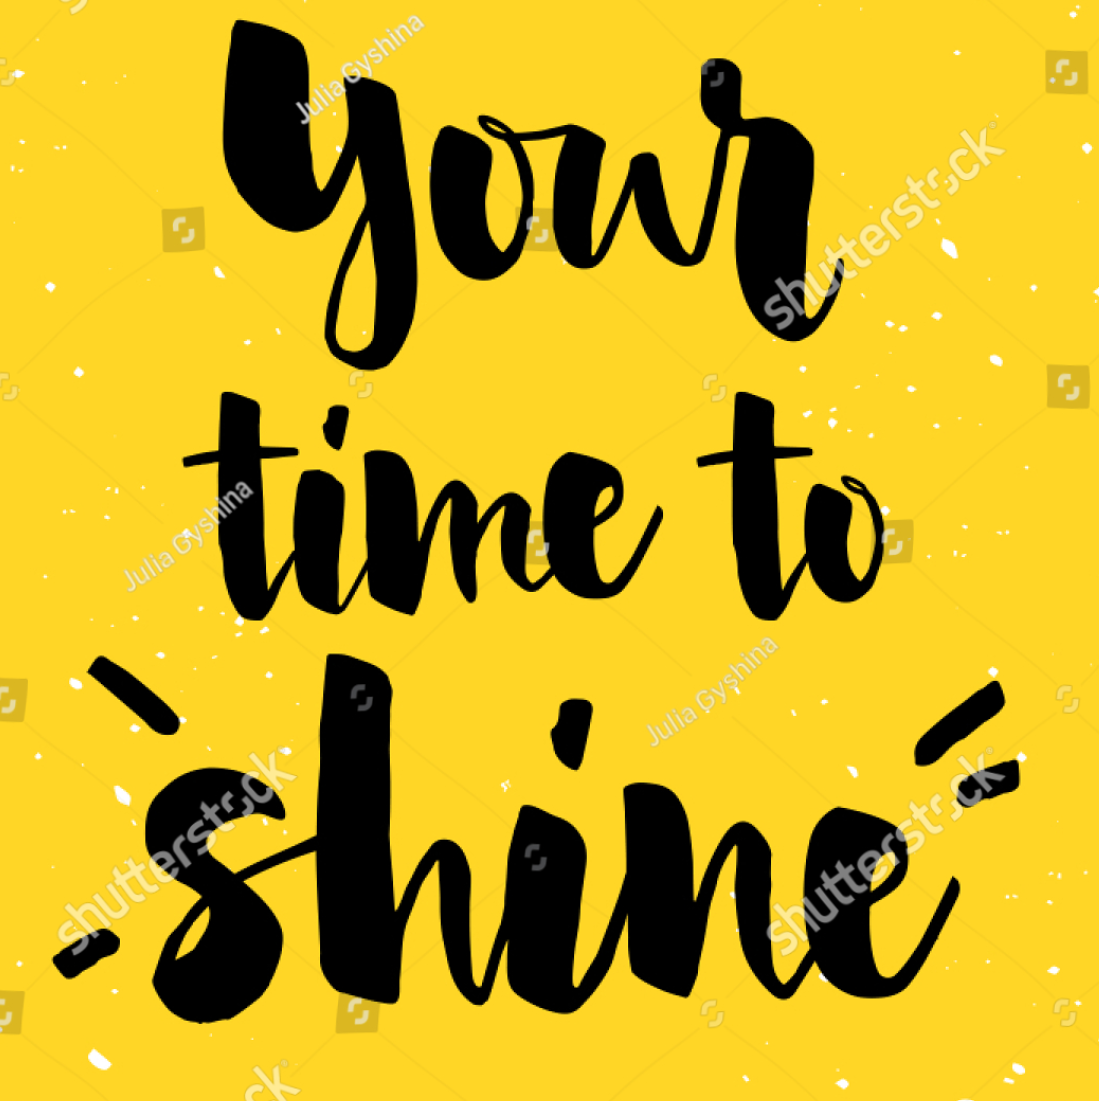

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, multivariate_normal
import scipy.stats as stats
from numpy.random import multivariate_normal as mvn_rnd

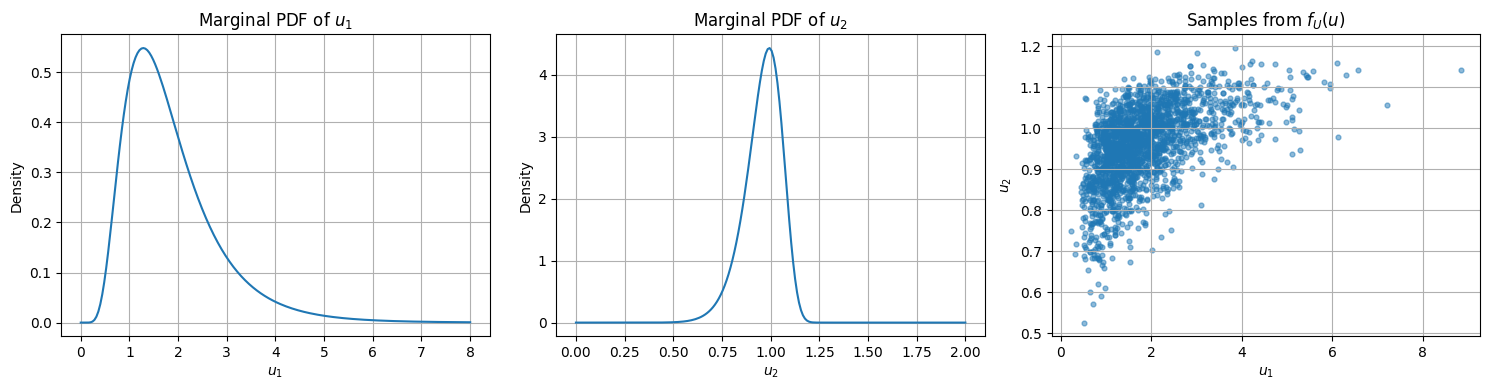

In [ ]:
#@title The Probabilistic Model -> Generate samples/scenarios $u\sim f_U(u)$.
def f_U(n_samples: int = 5000, seed: int = 42):
    """
    Generate samples u = (u1, u2) from the probabilistic model f_U(u).

    Returns
    -------
    U_phys : ndarray of shape (n_samples, 2)
        Samples in the physical space, with columns [u1, u2]
    marginals : list
        Marginal distributions of u1 and u2
    corr_matrix : ndarray of shape (2, 2)
        Gaussian copula correlation matrix
    """
    np.random.seed(seed)

    # Marginal distributions
    marginals = [
        stats.lognorm(s=0.5, scale=np.exp(0.5)),   # u1: random load
        stats.weibull_min(c=12.0, scale=1.0)       # u2: wind speed component
    ]

    # Correlation matrix in Gaussian space
    corr_matrix = np.array([
        [1.0, 0.6],
        [0.6, 1.0]
    ])

    # Step 1: sample correlated Gaussian variables
    Z = mvn_rnd(mean=np.zeros(2), cov=corr_matrix, size=n_samples)

    # Step 2: map to uniform variables through Gaussian CDF
    U_uniform = stats.norm.cdf(Z)

    # Step 3: map to physical space using inverse marginal CDFs
    U_phys = np.zeros_like(U_uniform)
    for i in range(2):
        U_phys[:, i] = marginals[i].ppf(U_uniform[:, i])

    return U_phys, marginals, corr_matrix


# Example (sample, marginal, correlation)
U, marginals, corr_matrix = f_U(2000)

# Grids for marginal PDFs
u1_grid = np.linspace(0, 8, 200)
u2_grid = np.linspace(0, 2, 200)

# Plot everything in one figure
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Marginal PDF of u1
axs[0].plot(u1_grid, marginals[0].pdf(u1_grid))
axs[0].set_title(r"Marginal PDF of $u_1$")
axs[0].set_xlabel(r"$u_1$")
axs[0].set_ylabel("Density")
axs[0].grid(True)

# Marginal PDF of u2
axs[1].plot(u2_grid, marginals[1].pdf(u2_grid))
axs[1].set_title(r"Marginal PDF of $u_2$")
axs[1].set_xlabel(r"$u_2$")
axs[1].set_ylabel("Density")
axs[1].grid(True)

# Joint samples
axs[2].scatter(U[:, 0], U[:, 1], alpha=0.5, s=12)
axs[2].set_title(r"Samples from $f_U(u)$")
axs[2].set_xlabel(r"$u_1$")
axs[2].set_ylabel(r"$u_2$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

#Start

In [ ]:
# Define the Performance Function g(x,theta)
def g_fun(u1, u2, design = None):
    """
    Performance function
    Args:
        u1, u2: Input variables.
        design: Design parameters
    Returns:
        Value of the performance function.
    """
    if design is None:
      design = [1, 1] # apply the baseline by default
      R = []
      S = []
      g = []
    return g

# Define the Indicator Function I(x)
def I_fun(x1, x2, design = None):
    """ """
    return

In [ ]:
# Monte Carlo Estimation
# 1. sample


# 2. evalluate system response

# 3. samples-based estimate
mc_estimate_pof = [] # COMPLETE...
print(f"Estimated probability of failure (small) = {mc_estimate_pof:.6f}")


In [ ]:
# Visualization of failure region

In [ ]:
# Convergence of the Pf estimator

In [ ]:
# Visualization of feasibility set